In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# PyTorch 核心库
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sklearn 库
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 可调参数 ---
# (P.S. 确保你的 project312 环境中已安装 torch: pip install torch)
LOOK_BACK = 72 # 使用过去 72 小时 (3 天) 的数据
N_FEATURES = 27 # 我们的 .csv 文件中的总特征数
BATCH_SIZE = 64
EPOCHS = 20

In [2]:
# --- 1. 加载数据 ---
processed_file_path = '../data/processed/cleaned_PRSA_Data.csv'
df = pd.read_csv(processed_file_path, parse_dates=True, index_col='datetime')

print("加载数据成功：")
print(df.info())

# --- 2. 重新排序，将 'PM2.5' 放在第一列 ---
cols = ['PM2.5'] + [col for col in df.columns if col != 'PM2.5']
df = df[cols]
print("\n将 'PM2.5' 移动到第一列后：")
print(df.head())

# 将 DataFrame 转换为 NumPy 数组
dataset = df.values.astype('float32')

加载数据成功：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   35064 non-null  float64
 1   PM10    35064 non-null  float64
 2   SO2     35064 non-null  float64
 3   NO2     35064 non-null  float64
 4   CO      35064 non-null  float64
 5   O3      35064 non-null  float64
 6   TEMP    35064 non-null  float64
 7   PRES    35064 non-null  float64
 8   DEWP    35064 non-null  float64
 9   RAIN    35064 non-null  float64
 10  WSPM    35064 non-null  float64
 11  wd_E    35064 non-null  bool   
 12  wd_ENE  35064 non-null  bool   
 13  wd_ESE  35064 non-null  bool   
 14  wd_N    35064 non-null  bool   
 15  wd_NE   35064 non-null  bool   
 16  wd_NNE  35064 non-null  bool   
 17  wd_NNW  35064 non-null  bool   
 18  wd_NW   35064 non-null  bool   
 19  wd_S    35064 non-null  bool   
 20  wd_SE   35064 non-null  bool 

In [3]:
# --- 3. 数据归一化 ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_dataset = scaler.fit_transform(dataset)

print(f"\n数据已归一化。")


数据已归一化。


In [4]:
# --- 4. 创建时间窗口函数 ---
def create_dataset_multivariate(scaled_data, look_back=LOOK_BACK, n_features=N_FEATURES):
    X, y = [], []
    for i in range(len(scaled_data) - look_back - 1):
        # a 是 X: 包含 look_back 个时间步，每个时间步有 n_features 个特征
        a = scaled_data[i:(i + look_back), :]
        X.append(a)
        # b 是 y: 仅仅是下一个时间步的第 0 列 (PM2.5)
        y.append(scaled_data[i + look_back, 0])
    return np.array(X), np.array(y)

# X 和 y 此时是 Numpy 数组
X, y = create_dataset_multivariate(scaled_dataset) 

print(f"\n创建时间窗口数据完成。")
print(f"X (Numpy) 的形状: {X.shape}") 
print(f"y (Numpy) 的形状: {y.shape}")


创建时间窗口数据完成。
X (Numpy) 的形状: (34991, 72, 27)
y (Numpy) 的形状: (34991,)


In [5]:
# --- 5. 划分训练集和测试集 (Numpy) ---
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[0:train_size, :, :], X[train_size:len(X), :, :]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"X_train (Numpy) 形状: {X_train.shape}, y_train (Numpy) 形状: {y_train.shape}")
print(f"X_test (Numpy) 形状: {X_test.shape}, y_test (Numpy) 形状: {y_test.shape}")

# --- 6. 转换为 PyTorch Tensors ---
# Keras/TensorFlow 在 .fit() 中自动完成这一步，PyTorch 需要我们手动做

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # view(-1, 1) 转换为 [N, 1] 形状

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(f"\nX_train (Tensor) 形状: {X_train_tensor.shape}, y_train (Tensor) 形状: {y_train_tensor.shape}")
print(f"X_test (Tensor) 形状: {X_test_tensor.shape}, y_test (Tensor) 形状: {y_test_tensor.shape}")

X_train (Numpy) 形状: (27992, 72, 27), y_train (Numpy) 形状: (27992,)
X_test (Numpy) 形状: (6999, 72, 27), y_test (Numpy) 形状: (6999,)

X_train (Tensor) 形状: torch.Size([27992, 72, 27]), y_train (Tensor) 形状: torch.Size([27992, 1])
X_test (Tensor) 形状: torch.Size([6999, 72, 27]), y_test (Tensor) 形状: torch.Size([6999, 1])


In [6]:
# --- 7. 设置 PyTorch DataLoader ---
# DataLoader 帮助我们管理数据批次 (Batching)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 8. 定义 LSTM 模型类 ---
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 定义 LSTM 层
        # batch_first=True 让输入形状为 (batch_size, seq_len, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)
        
        # 定义全连接层
        self.fc1 = nn.Linear(hidden_size, 25)
        self.fc2 = nn.Linear(25, output_size)

    def forward(self, x):
        # x 形状: (batch_size, LOOK_BACK, N_FEATURES)
        
        # 初始化隐藏状态和细胞状态
        # (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM 向前传播
        out, _ = self.lstm(x, (h0, c0)) 
        
        # 我们只取序列的最后一个时间步的输出
        # out 形状: (batch_size, seq_len, hidden_size)
        out = out[:, -1, :] # 变为: (batch_size, hidden_size)
        
        # 应用 Dropout
        out = self.dropout(out)
        
        # 通过全连接层
        out = self.fc1(out)
        out = self.fc2(out) # 最终形状: (batch_size, 1)
        return out

# --- 9. 实例化模型、定义损失和优化器 ---
# 检查是否有可用的 GPU (CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n将使用设备: {device}")

HIDDEN_SIZE = 50 # 隐藏层神经元数量 (同 Keras)
NUM_LAYERS = 2   # LSTM 堆叠层数 (Keras 里我们用了 2 层)

model = LSTMModel(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, 1, dropout=0.2).to(device)

# 定义损失函数 (MSE)
loss_function = nn.MSELoss()

# 定义优化器 (Adam)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\nPyTorch 模型结构:")
print(model)


将使用设备: cuda

PyTorch 模型结构:
LSTMModel(
  (lstm): LSTM(27, 50, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)



开始训练模型...
Epoch  1/20 | Train Loss: 0.002127 | Validation Loss: 0.000741
Epoch  2/20 | Train Loss: 0.000989 | Validation Loss: 0.000599
Epoch  3/20 | Train Loss: 0.000768 | Validation Loss: 0.000487
Epoch  4/20 | Train Loss: 0.000701 | Validation Loss: 0.000457
Epoch  5/20 | Train Loss: 0.000641 | Validation Loss: 0.000428
Epoch  6/20 | Train Loss: 0.000610 | Validation Loss: 0.000446
Epoch  7/20 | Train Loss: 0.000612 | Validation Loss: 0.000405
Epoch  8/20 | Train Loss: 0.000585 | Validation Loss: 0.000423
Epoch  9/20 | Train Loss: 0.000577 | Validation Loss: 0.000470
Epoch 10/20 | Train Loss: 0.000572 | Validation Loss: 0.000400
Epoch 11/20 | Train Loss: 0.000566 | Validation Loss: 0.000385
Epoch 12/20 | Train Loss: 0.000561 | Validation Loss: 0.000407
Epoch 13/20 | Train Loss: 0.000546 | Validation Loss: 0.000434
Epoch 14/20 | Train Loss: 0.000551 | Validation Loss: 0.000421
Epoch 15/20 | Train Loss: 0.000563 | Validation Loss: 0.000413
Epoch 16/20 | Train Loss: 0.000538 | Validat

C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2198542176.py:55: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_loss_curve_pytorch.png') # 保存损失曲线图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2198542176.py:55: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_loss_curve_pytorch.png') # 保存损失曲线图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2198542176.py:55: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_loss_curve_pytorch.png') # 保存损失曲线图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2198542176.py:55: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_loss_curve_pytorch.png') # 保存损失曲线图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2198542176.py:55: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu S

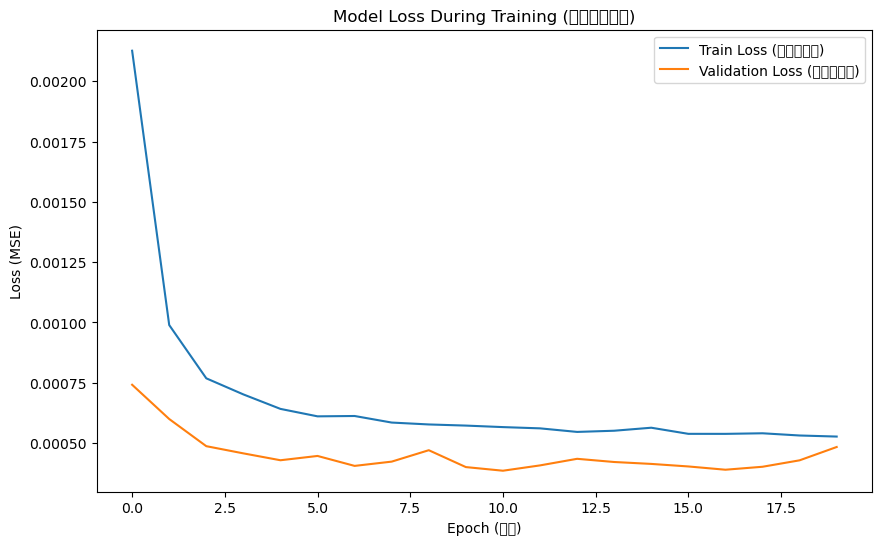

In [7]:
# --- 10. 训练模型 ---
print("\n开始训练模型...")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # --- 训练 ---
    model.train() # 将模型设置为训练模式
    batch_train_losses = []
    
    for X_batch, y_batch in train_loader:
        # 将数据移动到 GPU (如果可用)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. 前向传播
        outputs = model(X_batch)
        loss = loss_function(outputs, y_batch)
        
        # 2. 反向传播和优化
        optimizer.zero_grad() # 梯度清零
        loss.backward()       # 计算梯度
        optimizer.step()      # 更新权重
        
        batch_train_losses.append(loss.item())
    
    epoch_train_loss = np.mean(batch_train_losses)
    train_losses.append(epoch_train_loss)
    
    # --- 验证 (测试集) ---
    model.eval() # 将模型设置为评估模式
    batch_val_losses = []
    with torch.no_grad(): # 在评估时不计算梯度
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_outputs = model(X_val)
            val_loss = loss_function(val_outputs, y_val)
            batch_val_losses.append(val_loss.item())
            
    epoch_val_loss = np.mean(batch_val_losses)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Validation Loss: {epoch_val_loss:.6f}")

print("模型训练完成。")

# 可视化训练过程中的损失
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (训练集损失)')
plt.plot(val_losses, label='Validation Loss (测试集损失)')
plt.title('Model Loss During Training (模型训练损失)')
plt.xlabel('Epoch (轮次)')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.savefig('lstm_loss_curve_pytorch.png') # 保存损失曲线图
plt.show()

In [8]:
# --- 11. 评估模型与反归一化 ---

# 1. 进行预测 (PyTorch)
model.eval()
with torch.no_grad():
    # .to(device) 确保输入在 GPU/CPU 上
    # .cpu() 将结果从 GPU 移回 CPU
    # .numpy() 将 PyTorch Tensor 转换为 Numpy 数组
    train_predict_np = model(X_train_tensor.to(device)).cpu().numpy()
    test_predict_np = model(X_test_tensor.to(device)).cpu().numpy()

print(f"预测完成。测试集预测 (Numpy) 形状: {test_predict_np.shape}")
print(f"测试集真实值 (Numpy) 形状: {y_test.shape}")


# --- 2. "反归一化" 预测值 (与 Keras 步骤完全相同) ---
# (因为 scaler 和 y_test 都是在 Numpy 中操作的)

# 创建一个形状为 (样本数, 27) 的空数组
train_predict_full = np.zeros(shape=(len(train_predict_np), N_FEATURES))
# 只填充第 0 列 (PM2.5)
train_predict_full[:, 0] = train_predict_np.ravel()
# 进行反变换
inv_train_predict = scaler.inverse_transform(train_predict_full)[:, 0]

# 对测试集做同样的操作
test_predict_full = np.zeros(shape=(len(test_predict_np), N_FEATURES))
test_predict_full[:, 0] = test_predict_np.ravel()
inv_test_predict = scaler.inverse_transform(test_predict_full)[:, 0]

# 3. "反归一化" 真实值 (y_train, y_test)
y_train_full = np.zeros(shape=(len(y_train), N_FEATURES))
y_train_full[:, 0] = y_train.ravel()
inv_y_train = scaler.inverse_transform(y_train_full)[:, 0]

y_test_full = np.zeros(shape=(len(y_test), N_FEATURES))
y_test_full[:, 0] = y_test.ravel()
inv_y_test = scaler.inverse_transform(y_test_full)[:, 0]


# 4. 计算 RMSE 和 MAE (使用真实的 PM2.5 值)
train_rmse = np.sqrt(mean_squared_error(inv_y_train, inv_train_predict))
test_rmse = np.sqrt(mean_squared_error(inv_y_test, inv_test_predict))

train_mae = mean_absolute_error(inv_y_train, inv_train_predict)
test_mae = mean_absolute_error(inv_y_test, inv_test_predict)

print("\n--- 模型评估 (反归一化后) ---")
print(f"训练集 RMSE: {train_rmse:.2f}")
print(f"训练集 MAE:  {train_mae:.2f}")
print(f"测试集 RMSE: {test_rmse:.2f} (均方根误差，越低越好)")
print(f"测试集 MAE:  {test_mae:.2f} (平均绝对误差，越低越好)")

预测完成。测试集预测 (Numpy) 形状: (6999, 1)
测试集真实值 (Numpy) 形状: (6999,)

--- 模型评估 (反归一化后) ---
训练集 RMSE: 20.28
训练集 MAE:  13.63
测试集 RMSE: 19.70 (均方根误差，越低越好)
测试集 MAE:  13.35 (平均绝对误差，越低越好)


C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2990158807.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_prediction_vs_real_pytorch.png') # 保存预测对比图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2990158807.py:28: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_prediction_vs_real_pytorch.png') # 保存预测对比图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2990158807.py:28: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_prediction_vs_real_pytorch.png') # 保存预测对比图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2990158807.py:28: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.savefig('lstm_prediction_vs_real_pytorch.png') # 保存预测对比图
C:\Users\胡杨\AppData\Local\Temp\ipykernel_18604\2990158807.py:28: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C

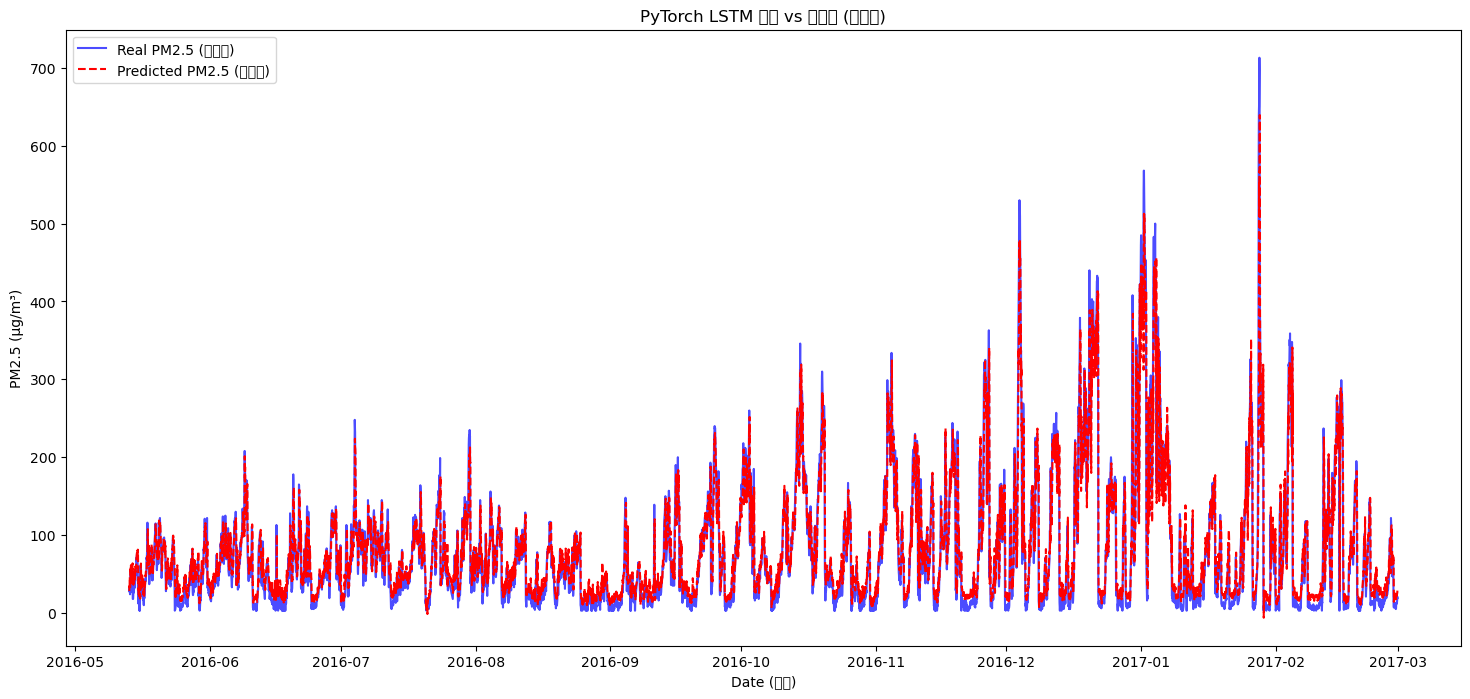

In [9]:
# --- 12. 可视化预测结果 (测试集) ---

# 测试集数据在原始数据中的起始索引
test_start_index = train_size + LOOK_BACK + 1

plt.figure(figsize=(18, 8))

# 绘制整个数据集的真实 PM2.5 值
real_data_range = df.iloc[test_start_index : test_start_index + len(inv_test_predict)]

plt.plot(real_data_range.index, 
         real_data_range['PM2.5'], 
         label='Real PM2.5 (真实值)', 
         color='blue', 
         alpha=0.7)

# 绘制模型的预测值
plt.plot(real_data_range.index, 
         inv_test_predict, 
         label='Predicted PM2.5 (预测值)', 
         color='red', 
         linestyle='--')

plt.title('PyTorch LSTM 预测 vs 真实值 (测试集)')
plt.xlabel('Date (日期)')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.savefig('lstm_prediction_vs_real_pytorch.png') # 保存预测对比图
plt.show()

In [10]:
# --- 单元格 A (修正版): 定义“黄金标准”交叉验证折 (Folds) ---
# 这个单元格取代了原来的 "单元格 5"

print("--- [步骤 A] 开始定义'黄金标准'交叉验证折 ---")

# 我们需要 'df', 'X', 'y', 和 'LOOK_BACK' 变量
# 'y' 中的第 i 个元素, 对应的 *预测目标日期* 是 df.index[i + LOOK_BACK + 1]
# 我们用这个关系来找到切分点
try:
    target_dates = df.index[LOOK_BACK + 1 : LOOK_BACK + 1 + len(y)]
    print(f"y 对应的目标日期范围: {target_dates.min()} 到 {target_dates.max()}")
except NameError as e:
    print(f"错误: 运行此单元格前, 请确保 'df', 'X', 'y' 和 'LOOK_BACK' 已被定义。")
    print(f"具体错误: {e}")
    raise

# --- 1. 找到各个时间点的索引 ---
# 找到 2015-01-01 在 y 中的起始索引
try:
    split_point_1 = target_dates.get_loc('2015-01-01 00:00:00')
    # 找到 2016-01-01 在 y 中的起始索引
    split_point_2 = target_dates.get_loc('2016-01-01 00:00:00')
    # 找到 2017-01-01 在 y 中的起始索引
    split_point_3 = target_dates.get_loc('2017-01-01 00:00:00')
except KeyError as e:
    print(f"错误: 无法在索引中找到确切的日期 {e}。这不应该发生。")
    print("请检查你的 'cleaned_PRSA_Data.csv' 文件是否完整。")
    raise

# 数据的终点
end_point = len(y)

# --- 2. 定义三个 Fold 的 (train_end_idx, test_end_idx) ---
# 索引是 "左闭右开" [start:end]
folds = [
    # Fold 1: 训练 [2013-2014], 测试 [2015]
    {
        "name": "预测 2015 年",
        "train_start": 0,
        "train_end": split_point_1,
        "test_start": split_point_1,
        "test_end": split_point_2
    },
    # Fold 2: 训练 [2013-2015], 测试 [2016]
    {
        "name": "预测 2016 年",
        "train_start": 0,
        "train_end": split_point_2,
        "test_start": split_point_2,
        "test_end": split_point_3
    },
    # Fold 3: 训练 [2013-2016], 测试 [2017]
    {
        "name": "预测 2017 年",
        "train_start": 0,
        "train_end": split_point_3,
        "test_start": split_point_3,
        "test_end": end_point
    }
]

print("\n成功定义了 3 个扩展窗口折 (Folds):")
for i, fold in enumerate(folds):
    print(f"  Fold {i+1} ({fold['name']}):")
    print(f"    训练集 (X, y) 索引: [{fold['train_start']}:{fold['train_end']}] (共 {fold['train_end'] - fold['train_start']} 个样本)")
    print(f"    测试集 (X, y) 索引: [{fold['test_start']}:{fold['test_end']}] (共 {fold['test_end'] - fold['test_start']} 个样本)")

# 用于存储每折分数的列表
all_mae_scores = []
all_rmse_scores = []

--- [步骤 A] 开始定义'黄金标准'交叉验证折 ---
y 对应的目标日期范围: 2013-03-04 01:00:00 到 2017-02-28 23:00:00

成功定义了 3 个扩展窗口折 (Folds):
  Fold 1 (预测 2015 年):
    训练集 (X, y) 索引: [0:16031] (共 16031 个样本)
    测试集 (X, y) 索引: [16031:24791] (共 8760 个样本)
  Fold 2 (预测 2016 年):
    训练集 (X, y) 索引: [0:24791] (共 24791 个样本)
    测试集 (X, y) 索引: [24791:33575] (共 8784 个样本)
  Fold 3 (预测 2017 年):
    训练集 (X, y) 索引: [0:33575] (共 33575 个样本)
    测试集 (X, y) 索引: [33575:34991] (共 1416 个样本)


In [11]:
# --- 单元格 B: 循环训练与评估 (黄金标准) ---
# 这个单元格取代了原来的 "单元格 7" 和 "单元格 8"

print("\n--- [步骤 B] 开始执行'黄金标准'扩展窗口评估 ---")
print(f"警告: 这将重新训练 LSTM 模型 {len(folds)} 次。总轮数: {EPOCHS} * {len(folds)} = {EPOCHS * len(folds)}")

# 确保 'device' 和 'LSTMModel' 类已定义
if 'device' not in locals() or 'LSTMModel' not in locals():
    print("错误: 'device' 或 'LSTMModel' 类未定义。请先运行单元格 1 和 6。")
    raise NameError

for i, fold in enumerate(folds):
    print(f"\n--- [开始 FOLD {i+1}/{len(folds)}: {fold['name']}] ---")
    
    # --- 1. 准备该 Fold 的数据 ---
    print(f"> 正在准备数据...")
    tr_start, tr_end = fold['train_start'], fold['train_end']
    te_start, te_end = fold['test_start'], fold['test_end']
    
    X_train_fold, y_train_fold = X[tr_start:tr_end], y[tr_start:tr_end]
    X_test_fold, y_test_fold = X[te_start:te_end], y[te_start:te_end]

    # 转换为 Tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
    # y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).view(-1, 1) # 评估时用 numpy 就好
    
    # 创建 DataLoaders
    train_dataset_fold = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True)
    
    # --- 2. 重新初始化模型和优化器 (关键!) ---
    # 每一折都必须是一个全新的模型
    model_fold = LSTMModel(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, 1, dropout=0.2).to(device)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model_fold.parameters(), lr=0.001)

    # --- 3. 训练模型 (在该 Fold 上) ---
    print(f"> 正在训练模型 ({EPOCHS} 轮)...")
    for epoch in range(EPOCHS):
        model_fold.train()
        batch_train_losses = []
        for X_batch, y_batch in train_loader_fold:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_fold(X_batch)
            loss = loss_function(outputs, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_train_losses.append(loss.item())
        
        # 打印最后一轮的损失
        if epoch == EPOCHS - 1:
            print(f"  > [Epoch {epoch+1}/{EPOCHS}] Fold Train Loss: {np.mean(batch_train_losses):.6f}")

    print("> 训练完成。")
    
    # --- 4. 评估模型 (在该 Fold 的测试集上) ---
    print("> D正在预测...")
    model_fold.eval()
    with torch.no_grad():
        test_predict_np = model_fold(X_test_tensor.to(device)).cpu().numpy()

    # --- 5. 反归一化并计算指标 ---
    # 创建 (N, 27) 的空数组
    test_predict_full = np.zeros(shape=(len(test_predict_np), N_FEATURES))
    # 填充第 0 列 (PM2.5)
    test_predict_full[:, 0] = test_predict_np.ravel()
    # 反归一化预测值
    inv_test_predict = scaler.inverse_transform(test_predict_full)[:, 0]
    
    # 反归一化真实值
    y_test_full = np.zeros(shape=(len(y_test_fold), N_FEATURES))
    y_test_full[:, 0] = y_test_fold.ravel()
    inv_y_test = scaler.inverse_transform(y_test_full)[:, 0]
    
    # 计算指标
    fold_rmse = np.sqrt(mean_squared_error(inv_y_test, inv_test_predict))
    fold_mae = mean_absolute_error(inv_y_test, inv_test_predict)
    
    all_rmse_scores.append(fold_rmse)
    all_mae_scores.append(fold_mae)
    
    print(f"> {fold['name']} 的 RMSE: {fold_rmse:.2f}")
    print(f"> {fold['name']} 的 MAE: {fold_mae:.2f}")
    print(f"--- [FOLD {i+1} 完成] ---")

print("\n\n--- [步骤 B] 扩展窗口评估全部完成 ---")


--- [步骤 B] 开始执行'黄金标准'扩展窗口评估 ---
警告: 这将重新训练 LSTM 模型 3 次。总轮数: 20 * 3 = 60

--- [开始 FOLD 1/3: 预测 2015 年] ---
> 正在准备数据...
> 正在训练模型 (20 轮)...
  > [Epoch 20/20] Fold Train Loss: 0.000546
> 训练完成。
> D正在预测...
> 预测 2015 年 的 RMSE: 19.45
> 预测 2015 年 的 MAE: 11.24
--- [FOLD 1 完成] ---

--- [开始 FOLD 2/3: 预测 2016 年] ---
> 正在准备数据...
> 正在训练模型 (20 轮)...
  > [Epoch 20/20] Fold Train Loss: 0.000529
> 训练完成。
> D正在预测...
> 预测 2016 年 的 RMSE: 17.58
> 预测 2016 年 的 MAE: 10.19
--- [FOLD 2 完成] ---

--- [开始 FOLD 3/3: 预测 2017 年] ---
> 正在准备数据...
> 正在训练模型 (20 轮)...
  > [Epoch 20/20] Fold Train Loss: 0.000497
> 训练完成。
> D正在预测...
> 预测 2017 年 的 RMSE: 24.48
> 预测 2017 年 的 MAE: 13.36
--- [FOLD 3 完成] ---


--- [步骤 B] 扩展窗口评估全部完成 ---


In [12]:
# --- 单元格 C: 打印最终“公平”对比结果 ---
# 这个单元格取代了原来的 "单元格 8 (部分)" 和 "单元格 9"

print("--- [步骤 C] 最终平均结果 (基于扩展窗口法) ---")

# 打印每一折的分数
print(f"每一折 (年) 的 RMSE 分数: {all_rmse_scores}")
print(f"每一折 (年) 的 MAE 分数: {all_mae_scores}")

# 计算平均值
avg_rmse = np.mean(all_rmse_scores)
avg_mae = np.mean(all_mae_scores)

print("\n--- 最终模型评估 (平均分数) ---")
print(f"LSTM (PyTorch) - 平均 RMSE: {avg_rmse:.2f}")
print(f"LSTM (PyTorch) - 平均 MAE:  {avg_mae:.2f}")

# 打印你之前提供的 ARIMA 和 Prophet 分数以供对比
print("\n--- 与其他模型对比 (使用你提供的数据) ---")
print(f"ARIMA(3, 0, 1) - 平均 MAE: 27.27 (RMSE: 38.22)")
print(f"Prophet        - 平均 MAE: 33.22 (RMSE: 42.37)")
print(f"LSTM (PyTorch) - 平均 MAE: {avg_mae:.2f} (RMSE: {avg_rmse:.2f})")

print("\n--- 结论 ---")
if avg_mae < 27.27 and avg_mae < 33.22:
    print("结论: LSTM (PyTorch) 模型在'黄金标准'评估下, 表现优于 ARIMA 和 Prophet。")
elif avg_mae < 33.22:
    print("结论: LSTM (PyTorch) 模型表现优于 Prophet, 但 ARIMA 表现最好。")
else:
    print("结论: LSTM (PyTorch) 模型的表现不如 ARIMA 或 Prophet。")

--- [步骤 C] 最终平均结果 (基于扩展窗口法) ---
每一折 (年) 的 RMSE 分数: [np.float64(19.445147727500043), np.float64(17.58341698530783), np.float64(24.484086047333513)]
每一折 (年) 的 MAE 分数: [11.236513019895801, 10.193631359668487, 13.357843047086996]

--- 最终模型评估 (平均分数) ---
LSTM (PyTorch) - 平均 RMSE: 20.50
LSTM (PyTorch) - 平均 MAE:  11.60

--- 与其他模型对比 (使用你提供的数据) ---
ARIMA(3, 0, 1) - 平均 MAE: 27.27 (RMSE: 38.22)
Prophet        - 平均 MAE: 33.22 (RMSE: 42.37)
LSTM (PyTorch) - 平均 MAE: 11.60 (RMSE: 20.50)

--- 结论 ---
结论: LSTM (PyTorch) 模型在'黄金标准'评估下, 表现优于 ARIMA 和 Prophet。
